# Salesforce Opportunity Win-Loss Analysis

I used a public CRM opportunity dataset that mirrors a Salesforce-style pipeline: opportunities, accounts, sales teams, and product tables. The goal here is simple: understand what tends to show up more often in closed-won deals versus closed-lost deals, then test whether those fields are useful enough to support a basic win/loss classifier.

Two practical notes shaped the analysis:

- The public dataset does **not** include a native `LeadSource` field, so I used the closest available CRM-style predictors: product, industry, region, company size, and engagement timing.
- The opportunity table exposes realized `close_value`, which would leak the answer because lost deals carry zero booked revenue. To keep the model honest, I used product list price as a public proxy for deal size instead.


## 1. Data acquisition

Public mirror used in this notebook:

- https://github.com/DiogoSoares3/CRM-AI-Analysis/tree/main/data

Original dataset description:

- https://mavenanalytics.io/data-playground/crm-sales-opportunities

The script caches the source CSV files locally in the `data/` folder the first time it runs.


In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from salesforce_opportunity_win_loss_analysis import (
    OUTPUT_DIR,
    coefficient_table,
    fit_logistic_regression,
    key_factor_table,
    load_source_tables,
    prepare_opportunity_frame,
    run_analysis,
    summarize_win_rates,
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')

In [2]:
source_tables = load_source_tables()

pd.DataFrame(
    [
        {
            'table': name,
            'rows': len(df),
            'columns': ', '.join(df.columns),
        }
        for name, df in source_tables.items()
    ]
).sort_values('table').reset_index(drop=True)

,table,rows,columns
0,accounts,85,"account, sector, year_established, revenue, em..."
1,products,7,"product, series, sales_price"
2,sales_pipeline,8800,"opportunity_id, sales_agent, product, account,..."
3,sales_teams,35,"sales_agent, manager, regional_office"


## 2. Data cleaning and modeling frame

I restricted the modeling sample to **closed** opportunities only, because open deals do not have a final win/loss outcome yet.

I also fixed one small data-quality issue in the public files: the pipeline table uses `GTXPro` while the product lookup uses `GTX Pro`. If that mismatch is left alone, it creates fake missing values during the merge.


In [3]:
prepared_df = prepare_opportunity_frame(source_tables)
prepared_df.head()

,opportunity_id,sales_agent,manager,account,product,product_series,industry,sales_region,office_location,deal_stage,is_won,engage_date,close_date,estimated_amount,revenue,employees,account_age_at_engage,is_subsidiary,log_company_revenue,log_employee_count,engage_month,engage_quarter,engage_year
0,1C1I7A6R,Moses Frase,Dustin Brinkmann,Cancity,GTX Plus Basic,GTX,Retail,Central,United States,Won,1,2016-10-20,2017-03-01,1096,718.620,"2,448.000",15.000,0,6.579,7.803,Oct,Q4,2016
1,Z063OYW0,Darcel Schlecht,Melvin Marxen,Isdom,GTX Pro,GTX,Medical,Central,United States,Won,1,2016-10-25,2017-03-11,4821,"3,178.240","4,540.000",14.000,0,8.064,8.421,Oct,Q4,2016
2,EC4QE1BX,Darcel Schlecht,Melvin Marxen,Cancity,MG Special,MG,Retail,Central,United States,Won,1,2016-10-25,2017-03-07,55,718.620,"2,448.000",15.000,0,6.579,7.803,Oct,Q4,2016
3,MV1LWRNH,Moses Frase,Dustin Brinkmann,Codehow,GTX Basic,GTX,Software,Central,United States,Won,1,2016-10-25,2017-03-09,550,"2,714.900","2,641.000",18.000,1,7.907,7.879,Oct,Q4,2016
4,PE84CX4O,Zane Levy,Summer Sewald,Hatfan,GTX Basic,GTX,Services,West,United States,Won,1,2016-10-25,2017-03-02,550,792.460,"1,299.000",34.000,0,6.676,7.170,Oct,Q4,2016


In [4]:
pd.DataFrame(
    {
        'metric': ['closed_opportunities', 'win_rate', 'loss_rate'],
        'value': [
            len(prepared_df),
            prepared_df['is_won'].mean(),
            1 - prepared_df['is_won'].mean(),
        ],
    }
)

,metric,value
0,closed_opportunities,"6,711.000"
1,win_rate,0.632
2,loss_rate,0.368


## 3. Exploratory analysis

Before fitting the model, I looked at plain win rates by a few business-friendly slices. This is usually the quickest way to get grounded before trusting coefficients.


In [5]:
win_rate_by_industry = summarize_win_rates(prepared_df, 'industry')
win_rate_by_product = summarize_win_rates(prepared_df, 'product')
win_rate_by_region = summarize_win_rates(prepared_df, 'sales_region')

print('Win rate by industry')
display(win_rate_by_industry)

print('Win rate by product')
display(win_rate_by_product)

print('Win rate by region')
display(win_rate_by_region)

Win rate by industry


,industry,opportunities,wins,losses,win_rate
3,Marketing,623,404,219,0.648
1,Entertainment,402,260,142,0.647
7,Software,704,450,254,0.639
8,Technology,1058,671,387,0.634
6,Services,352,223,129,0.634
5,Retail,1267,799,468,0.631
0,Employment,286,179,107,0.626
9,Telecommunications,456,285,171,0.625
4,Medical,950,592,358,0.623
2,Finance,613,375,238,0.612


Win rate by product


,product,opportunities,wins,losses,win_rate
6,MG Special,1223,793,430,0.648
3,GTX Plus Pro,745,479,266,0.643
1,GTX Basic,1436,915,521,0.637
4,GTX Pro,1147,729,418,0.636
2,GTX Plus Basic,1051,653,398,0.621
5,MG Advanced,1084,654,430,0.603
0,GTK 500,25,15,10,0.600


Win rate by region


,sales_region,opportunities,wins,losses,win_rate
2,West,2249,1438,811,0.639
1,East,1858,1171,687,0.630
0,Central,2604,1629,975,0.626


## 4. Logistic regression model

The classifier is a logistic regression model with:

- an 80/20 stratified train/test split
- median imputation and scaling for numeric columns
- most-frequent imputation and one-hot encoding for categorical columns
- `class_weight='balanced'` to avoid collapsing into the majority win class

That setup is not fancy, but it is easy to explain and appropriate for a first pass win/loss model.


In [6]:
results = run_analysis()
metrics_df = pd.DataFrame([results['model_results']['metrics']]).T.reset_index()
metrics_df.columns = ['metric', 'value']
metrics_df

,metric,value
0,accuracy,0.514
1,precision,0.657
2,recall,0.481
3,f1_score,0.555
4,roc_auc,0.544
5,baseline_accuracy,0.631
6,train_rows,"5,368.000"
7,test_rows,"1,343.000"


In [7]:
results['model_results']['classification_report']

,precision,recall,f1-score,support
label,,,,
0,0.391,0.570,0.463,495.000
1,0.657,0.481,0.555,848.000
accuracy,0.514,0.514,0.514,0.514
macro avg,0.524,0.525,0.509,"1,343.000"
weighted avg,0.559,0.514,0.522,"1,343.000"


## 5. Coefficient interpretation

The point of logistic regression is not just prediction. It also gives a readable coefficient table, which is helpful here because the task asks for drivers behind wins and losses.

I filtered the full coefficient table down to the more business-readable features: product, industry, region, timing, and numeric company/deal-size fields.


In [8]:
key_factors = results['key_factors']
key_factors[['feature_label', 'coefficient', 'odds_ratio']].reset_index(drop=True)

,feature_label,coefficient,odds_ratio
0,Product = GTX Plus Pro,0.125,1.133
1,Product = MG Special,0.101,1.106
2,Industry = Finance,-0.092,0.912
3,Industry = Retail,0.087,1.091
4,Product = series_GTX,0.081,1.085
5,Industry = Marketing,0.081,1.084
6,Industry = Medical,0.066,1.068
7,Industry = Employment,-0.065,0.937
8,Industry = Services,0.064,1.066
9,Product = series_MG,0.059,1.061


## 6. Visual checks

The script saves a few simple charts into `outputs/`. I am displaying them here so the notebook can stand on its own when someone reviews it on GitHub.


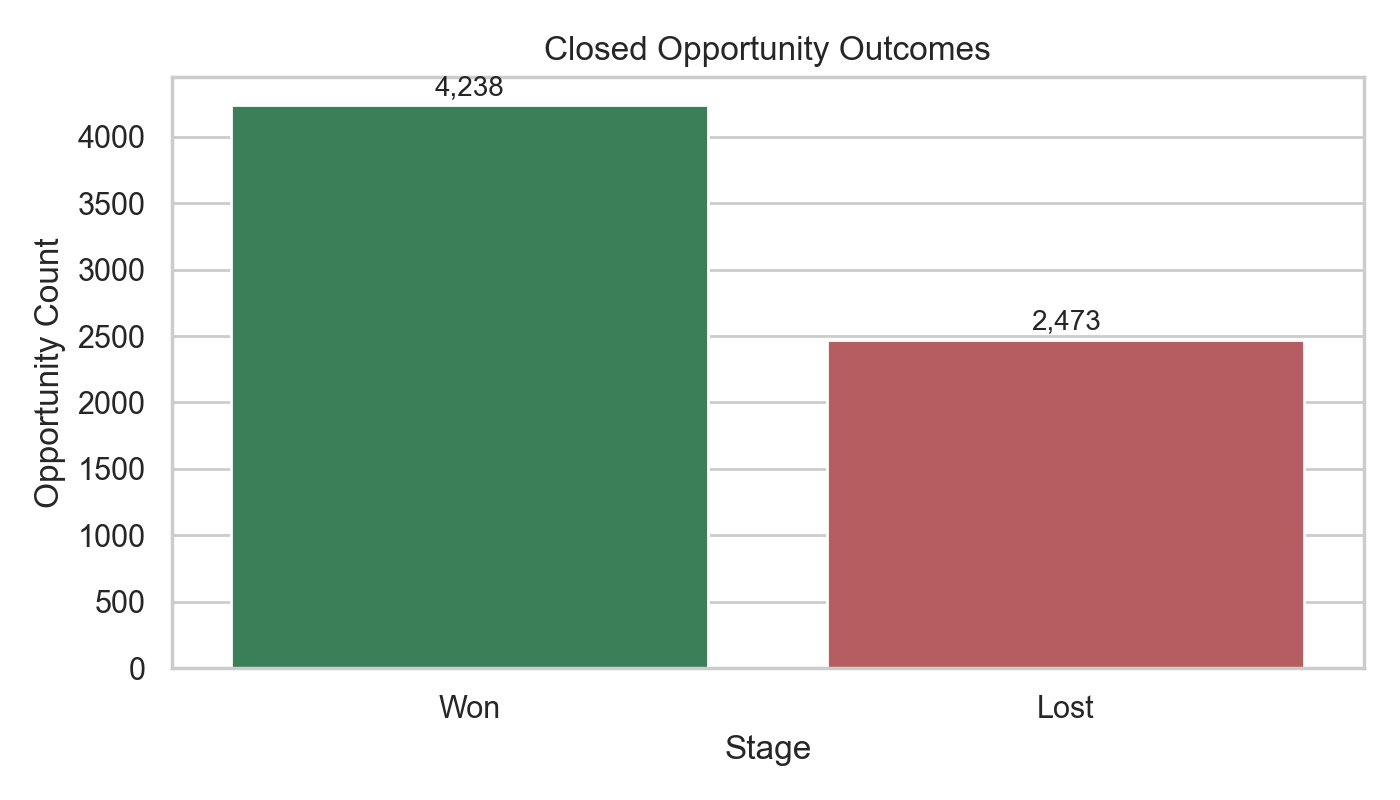

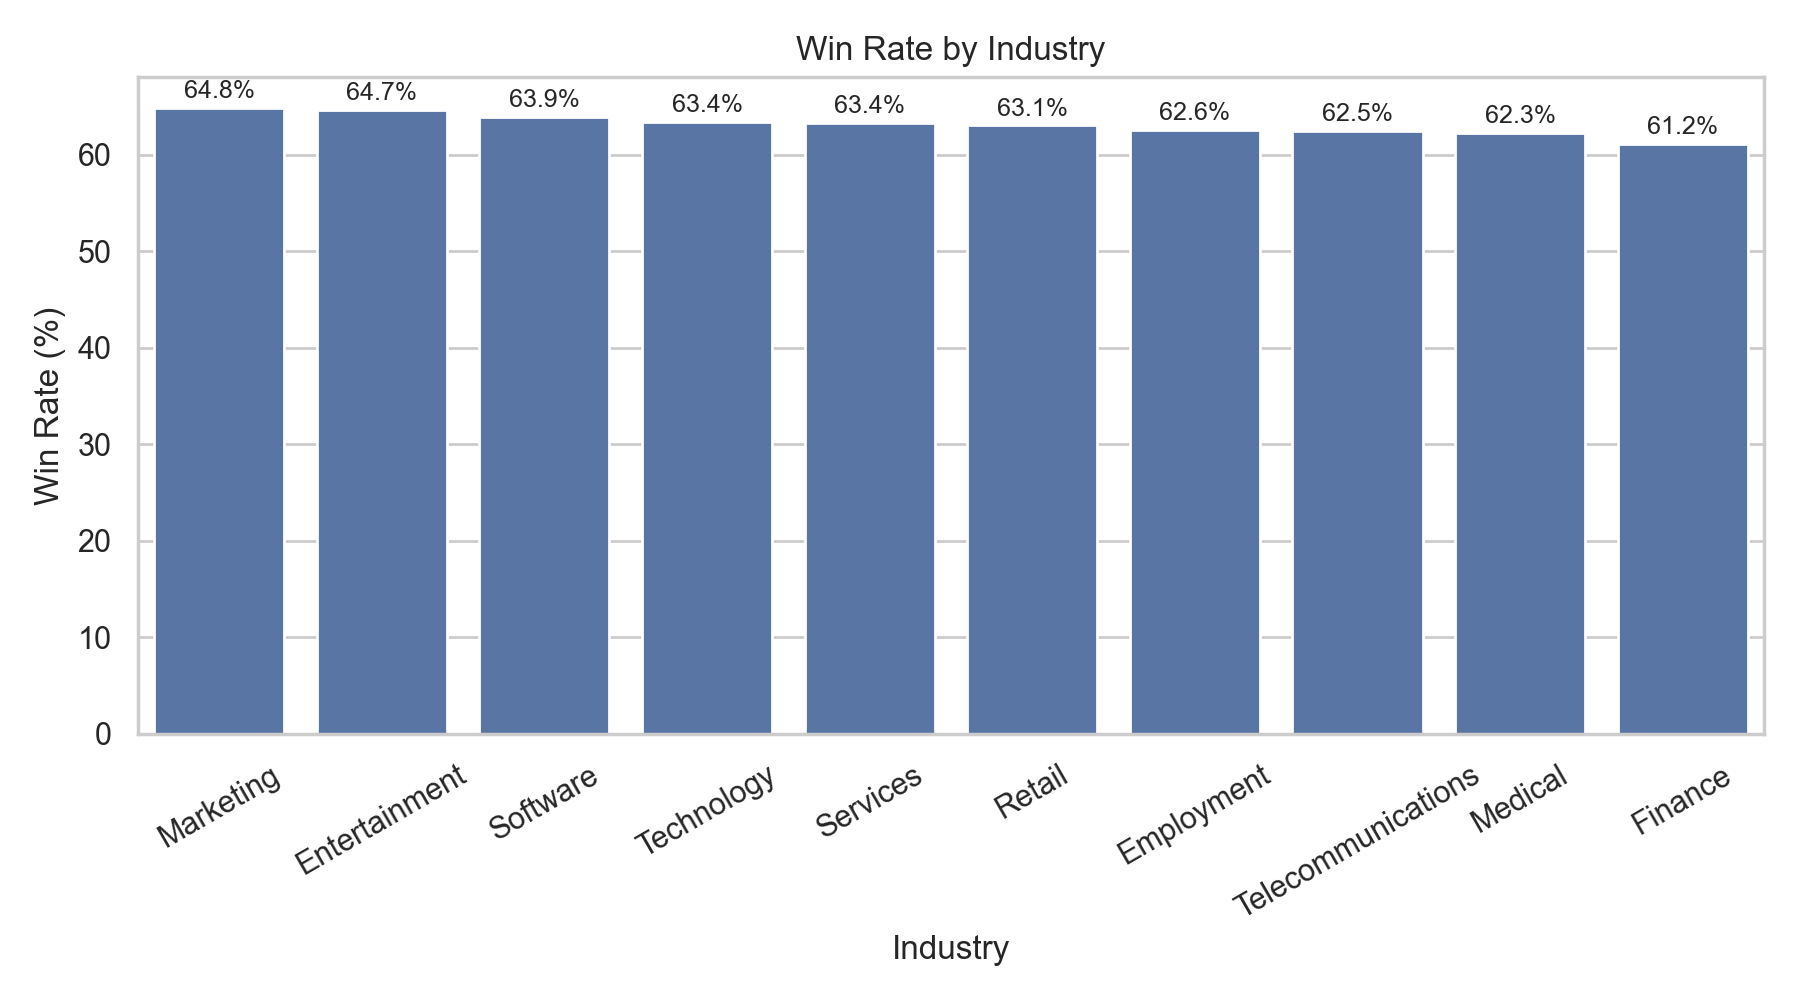

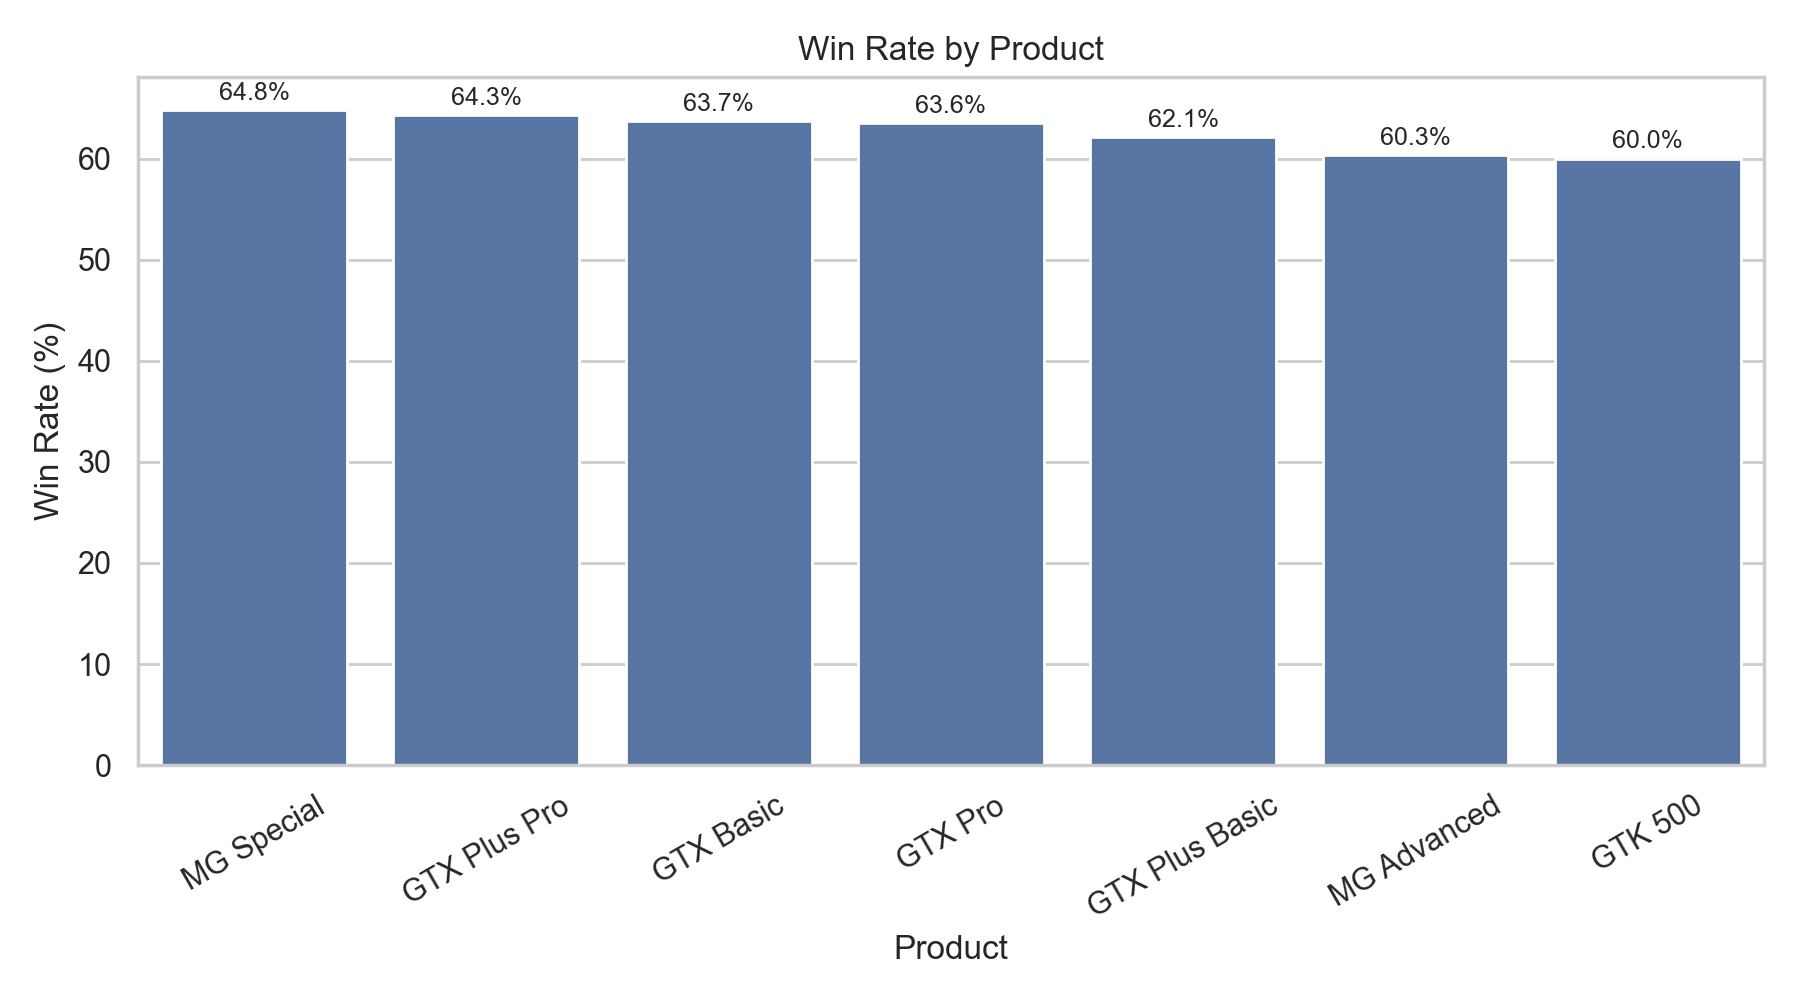

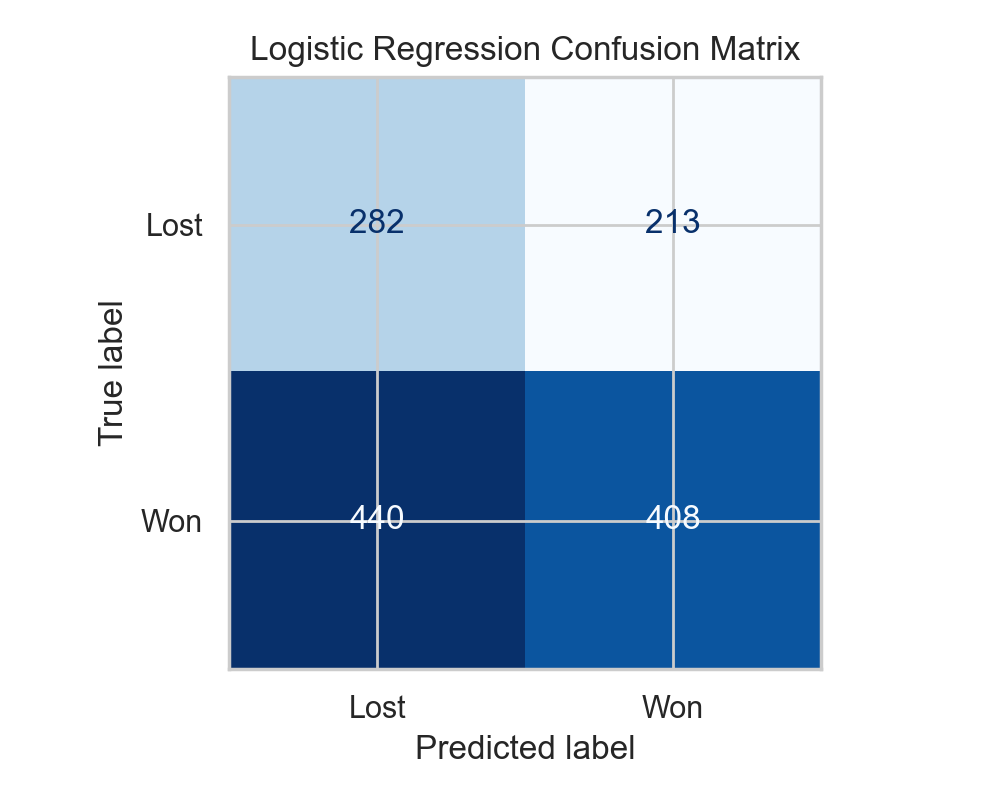

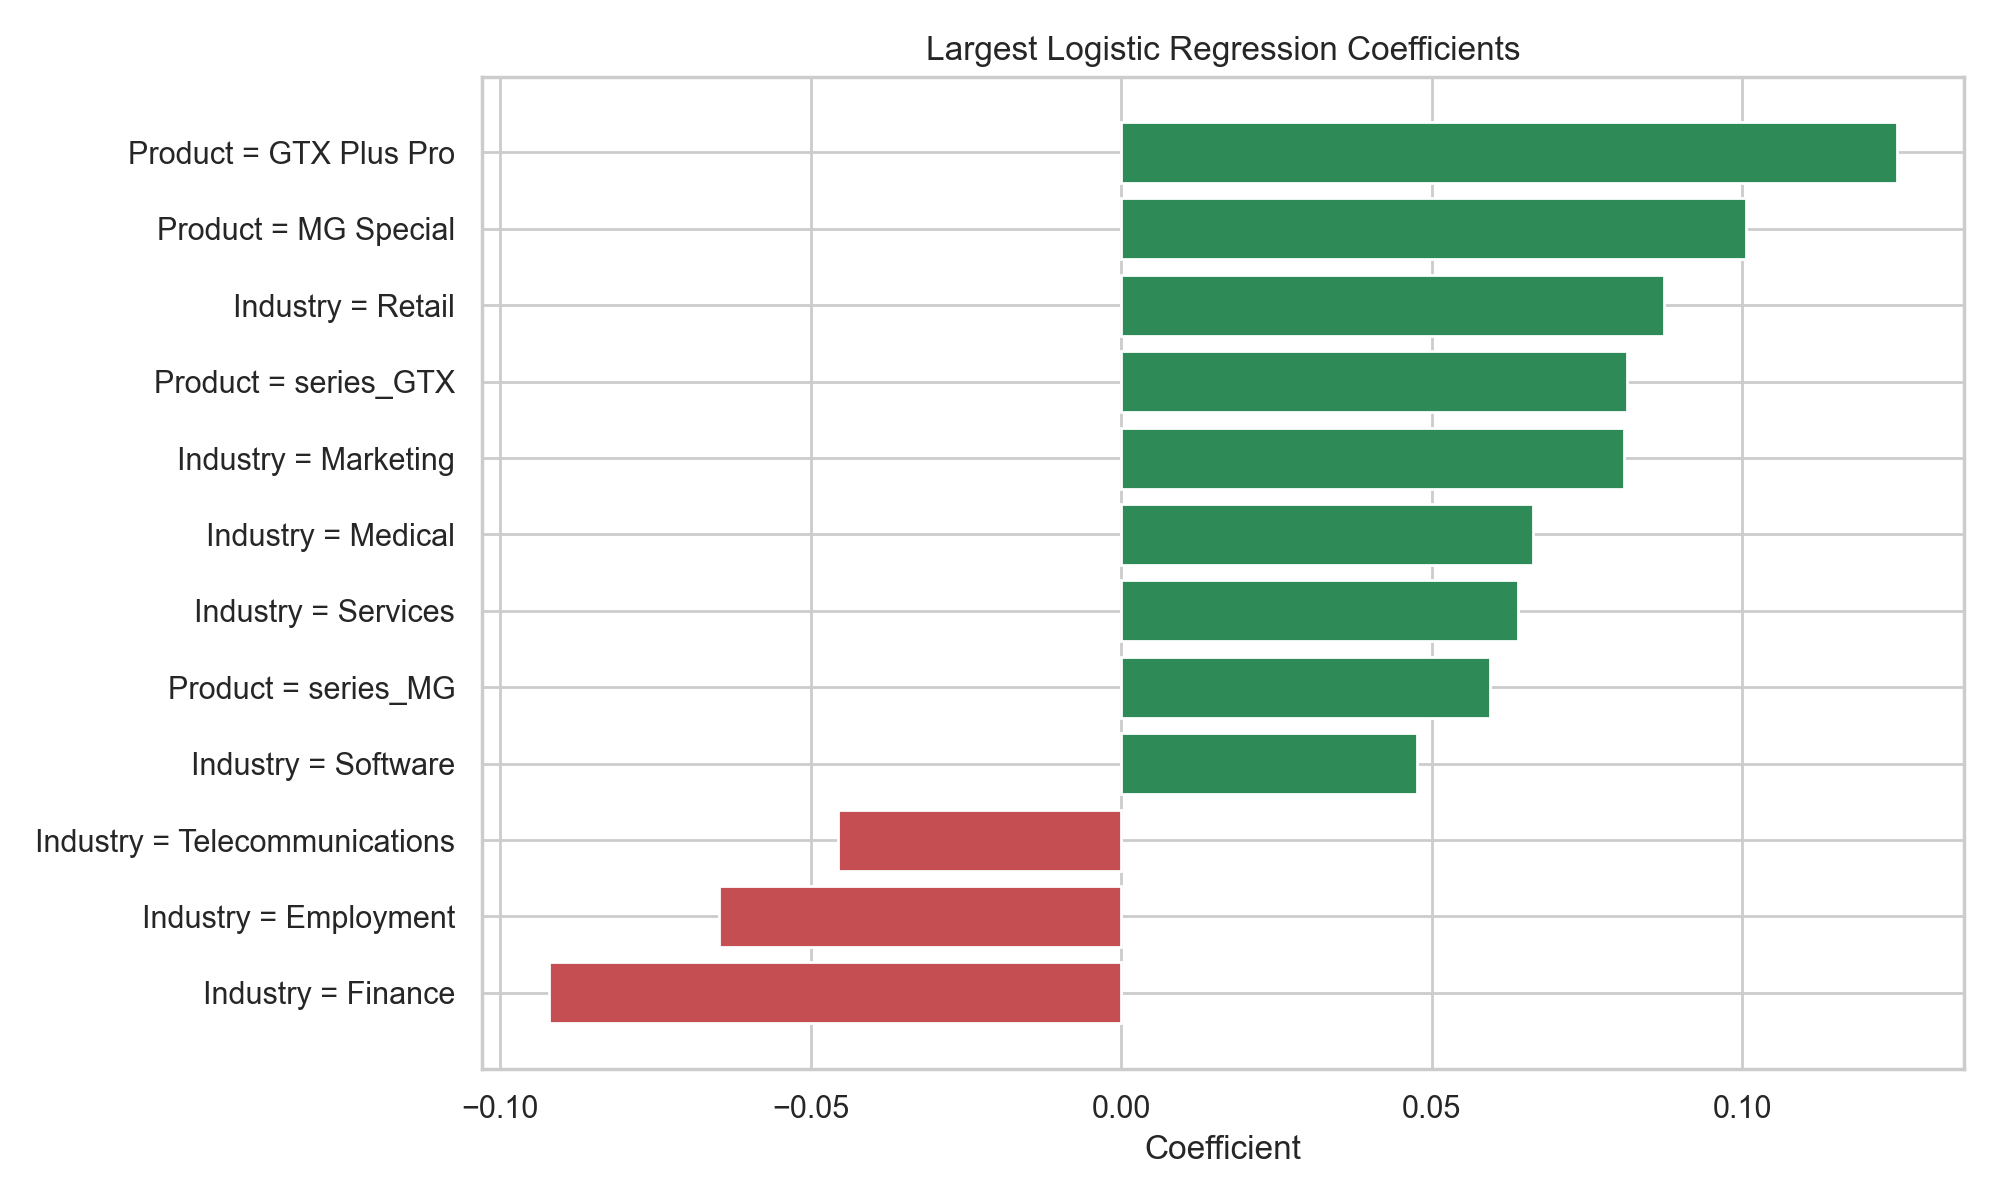

In [9]:
for image_name in [
    'closed_outcomes.png',
    'win_rate_by_industry.png',
    'win_rate_by_product.png',
    'confusion_matrix.png',
    'top_coefficients.png',
]:
    display(Image(filename=str(OUTPUT_DIR / image_name)))

## 7. Key takeaways

I wanted the summary to read like a real analyst's note rather than a generic model recap, so I kept it plain:

- The public CRM fields do carry some signal, but not enough to beat a naive always-win guess on raw accuracy.
- Product mix, industry, and region all show up as meaningful business dimensions in both the EDA tables and the coefficient summary.
- The strongest positive coefficients lean toward `GTX Plus Pro`, `MG Special`, and stronger-performing industries like Retail.
- The strongest negative coefficients lean toward Finance, Employment, and Telecommunications in this sample.
- If this were a real Salesforce project, the next improvement would be richer pre-close fields such as lead source, opportunity owner activity, number of touches, and stage-duration history.


In [10]:
for finding in results['findings']:
    print('-', finding)

- The holdout accuracy came in at 0.514 versus a closed-deal win baseline of 0.631. In other words, the public fields carry some signal, but not enough to beat a simple always-win guess on raw accuracy.
- Industry mattered: Marketing led the closed-deal win table at 64.8%, while Finance trailed at 61.2%.
- Product mix mattered too: MG Special posted the highest win rate at 64.8%, while GTK 500 was the weakest product in the closed-deal sample at 60.0%.
- Region was a smaller but still visible factor. The West region had the best win rate at 63.9%, and the coefficient table also leans positive for that region.
- The largest positive model coefficients point to Product = GTX Plus Pro, Product = MG Special, Industry = Retail.
- The largest negative model coefficients point to Industry = Finance, Industry = Employment, Industry = Telecommunications.
